In [49]:
import pickle

In [50]:
savesimdir = '../results/simulations/pickles/'

In [51]:
N_range = [50] # [1,2] # [5, 10, 20, 50,  75, 100, 150,  250,  400, 500] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
linear_slope_variance_range = [0.1] #[0.0, 0.4, 0.8, 1.0]
linear_intercept_variance_range = [0.1] # [0.0, 0.4, 0.8, 1.0]
numcells_to_swap_range = [2] # [1, 2, 16, 50] # , 16] #[0, 2, 8, 16, 64, 250]
nneigh_range = [10]
nbd_swaps_range = [2]
   

In [52]:

import scanpy as sc 

import anndata

In [53]:

spa_celltype_key='Types'


scrna_cluster_key = "Cell class (determined from clustering of all cells)"


adata_sc = sc.read("../data/scrnaseq_raw.h5ad")

common_celltypes = list(set(adata_sc.obs[scrna_cluster_key])) # define this according to dataset

In [54]:
adata_sc

AnnData object with n_obs × n_vars = 25326 × 133
    obs: 'Sex', 'Replicate number', 'Cell class (determined from clustering of all cells)', 'Non-neuronal cluster (determined from clustering of all cells)', 'Neuronal cluster (determined from clustering of inhibitory or excitatory neurons)', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'batch', 'doublet_score', 'predicted_doublet', 'clusters', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Mrpl', 'Mrps', 'Rpl', 'Rps'
    uns: 'Cell class (determined from clustering of all cells)_c

In [55]:
# adata_sc

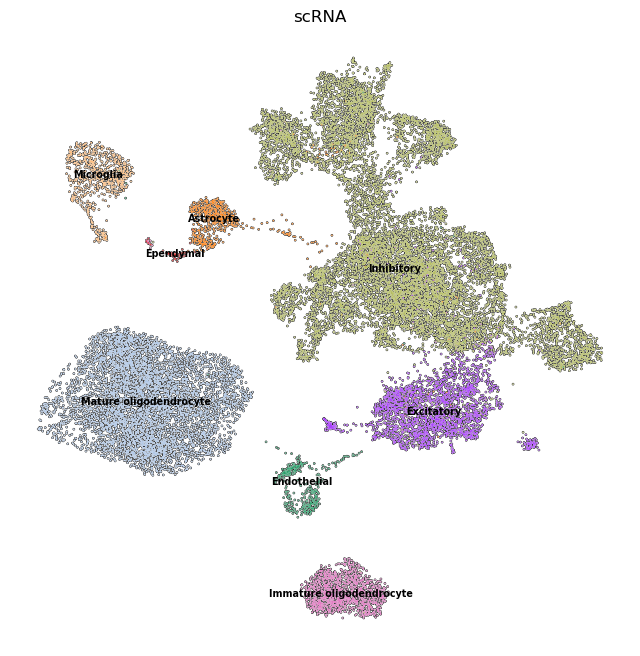

In [56]:
from matplotlib import colors
import matplotlib.pyplot as plt
# color_map
# sc.settings.set_figure_params(dpi=120)

plt.rcParams['figure.figsize']=(8,8) #rescale figures
# sc.settings.verbosity = 3

# sc.set_figure_params(scanpy=True, dpi_save=400,dpi=150)

# plt.rcParams["font.family"] = "Arial"
plt.rcParams['pdf.fonttype'] = 42



sc.pl.umap(adata_sc, add_outline=True, legend_fontsize='x-small',frameon=False,color='Cell class (determined from clustering of all cells)',title='scRNA',legend_loc='on data')# ,save='_scRNAcelltypes.png')

In [ ]:
# perform QC for reference based on 1st spatial sample 


save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N_range[0]) + '_linear_slope_var_' + str(linear_slope_variance_range[0]) + '_linear_int_var_' + str(linear_intercept_variance_range[0]) + '_' + str(numcells_to_swap_range[0]) + '.pickle'

with open(save_sim_file, 'rb') as handle:
    tmpa = pickle.load(handle)  
entry0 = list(tmpa.keys())[0]
entry1 = list(tmpa[entry0].keys())[0]
entry2 = list(tmpa[entry0][entry1].keys())[0]

genes_to_use = list((set(tmpa[entry0][entry1][entry2].var.index).intersection(set(adata_sc.var.index))))
print(len(genes_to_use))
genes_to_use.sort()
adata_sc =  anndata.AnnData(X=adata_sc.to_df()[genes_to_use],obs=adata_sc.obs,uns=adata_sc.uns,obsm=adata_sc.obsm)
sc.pp.filter_cells(adata_sc,min_counts=1)

norm_fac = adata_sc.to_df().sum(axis=1)

sc.pp.normalize_total(adata_sc, target_sum=1000)

print(adata_sc.to_df().sum(axis=1).median())

# # sc.pp.log1p(adata_sc)

# print(adata_sc.to_df().sum(axis=1).median())

adata_sc = adata_sc[adata_sc.obs[scrna_cluster_key].isin(common_celltypes)]

# highly variable gene selection 

# save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N_range[0]) + '_linear_slope_var_' + str(linear_slope_variance_range[0]) + '_linear_int_var_' + str(linear_intercept_variance_range[0]) + '_' + str(numcells_to_swap_range[0]) + '.pickle'

# with open(save_sim_file, 'rb') as handle:
#     tmpa = pickle.load(handle)  
# entry0 = list(tmpa.keys())[0]
# entry1 = list(tmpa[entry0].keys())[0]
# entry2 = list(tmpa[entry0][entry1].keys())[0]

# genes_to_use = list((set(tmpa[entry0][entry1][entry2].var.index).intersection(set(adata_sc.var.index))))
# print(len(genes_to_use))
# genes_to_use.sort()
# adata_sc =  anndata.AnnData(X=adata_sc.to_df()[genes_to_use],obs=adata_sc.obs,uns=adata_sc.uns,obsm=adata_sc.obsm)
# sc.pp.filter_cells(adata_sc,min_counts=1)

# print(adata_sc.to_df().sum(axis=1).median())


if adata_sc.shape[1] > 1500:
    
    sc.tl.rank_genes_groups(adata_sc, groupby=scrna_cluster_key, method="wilcoxon")
    sc.tl.filter_rank_genes_groups(adata_sc,   key_added='rank_genes_groups_filtered',  min_fold_change=1.5)
    all_genes = sc.get.rank_genes_groups_df(adata_sc,group=None, key='rank_genes_groups_filtered', pval_cutoff=0.05, log2fc_min=1.5)
    all_genes = all_genes[~all_genes['names'].isna()]
    adata_sc = adata_sc[:,list(set(all_genes['names']))]
    disp_columns = []
    for ct in set(adata_sc.obs[scrna_cluster_key].values):
        adata_sc.var[ct + '_disperson'] = 0.0
        disp_columns.append(ct + '_disperson')
        tmpa = adata_sc[adata_sc.obs[scrna_cluster_key]==ct].copy()

        tmpb = tmpa.to_df().var() / (tmpa.to_df().mean() + 0.000001)

        adata_sc.var[ct + '_disperson'] = tmpb


    adata_sc.var['avg_dispersion'] = adata_sc.var[disp_columns].mean(axis=1)
    import numpy as np
    top_pct = np.quantile(a=adata_sc.var['avg_dispersion'], q=0.99)

    adata_sc = adata_sc[:,adata_sc.var['avg_dispersion'] < top_pct]
    

adata_sc.write_h5ad("../data/scrna_ref_normnolog_nov2024_1k.h5ad")



133
1000.0


In [ ]:

#cnt = 0
# N_range = [5, 10, 50,  100,  200,  400] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
# nswaps_nbd_range = [2, 5, 10, 20, 50, 100]
# nneigh_range = [10]
N_range = [25,  75,  125, 150, 175] # [5, 10, 50,  100,  200] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
nswaps_nbd_range = [2]#, 5, 10, 20, 50, 100]
nneigh_range = [10]

for N in N_range:
        # for linear_slope_variance in linear_slope_variance_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        #     for linear_intercept_variance in linear_intercept_variance_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        for nneigh in nneigh_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
            for nbdswaps in nswaps_nbd_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
                # for numcells_to_swap in numcells_to_swap_range:#[0, 2, 4, 8, 16, 32, 64, 128, 256]:
                    # save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '.pickle'
                    # write_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '_normnolog_nov2024_1k.pickle'
                    save_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '.pickle'
                    write_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_normnolog_nov2024_1k.pickle'
                    
                    with open(save_sim_file, 'rb') as handle:
                        adata_spot_swap = pickle.load(handle)

                    for entry0 in adata_spot_swap.keys():
                        for entry1 in adata_spot_swap[entry0].keys(): 
                            for entry2 in adata_spot_swap[entry0][entry1].keys():
                                #adata_st = adata_spot_swap[entry0][entry1][entry2].copy()
                                


                                #Common genes 
                                # Normalize (10k)
                                # Log transform 
                                # Cell-type selection  -> model simplification
                                # Gene selection (from reference) – if number of genes > 1.5k
                                # DE genes (min_pct in cluster = 0.25, outside cluster = 0.5, logfc=1.5, p-val=0.05)
                                # Exclude top 1% of dispersed genes (tune such that number of net genes < 1.5k) 

                                genes_to_use = list((set(adata_sc.var.index).intersection(set(adata_spot_swap[entry0][entry1][entry2].var.index))))
                                print(len(genes_to_use))
                                genes_to_use.sort()

                                # # adata_sc_curr = adata_sc.copy()
                                

                                # # adata_st = adata_st.copy()
                                adata_st =  anndata.AnnData(X=adata_spot_swap[entry0][entry1][entry2].to_df()[genes_to_use],obs=adata_spot_swap[entry0][entry1][entry2].obs,uns=adata_spot_swap[entry0][entry1][entry2].uns,obsm=adata_spot_swap[entry0][entry1][entry2].obsm)

                                

                                sc.pp.normalize_total(adata_st, target_sum=1000)

                                
                                adata_spot_swap[entry0][entry1][entry2] = adata_st.copy()

                    with open(write_sim_file, 'wb') as handle:
                        pickle.dump(adata_spot_swap, handle, protocol=pickle.HIGHEST_PROTOCOL)
        


















133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133
133


## extract raw scRNA counts / metadata for CARD / cell2location 

- read raw 
- read normalized
- subset raw to normalized 
- save scRNAseq raw, as well as raw csvs 

In [47]:
import scanpy as sc

adata_sc_raw  = sc.read("../data/scrnaseq_raw.h5ad")

adata_sc = sc.read( "../data/scrna_ref_normnolog_nov2024_1k.h5ad")

adata_sc_raw = adata_sc_raw[adata_sc.obs.index,adata_sc.var.index]

adata_sc_raw.to_df().to_csv("../data/scrnaseq_raw.csv")

adata_sc_raw.obs.to_csv("../data/scrnaseq_metadata.csv")

adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

In [45]:
adata_sc_raw = adata_sc_raw.copy()

for entry in ['hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'phase_colors', 'scrublet', 'umap']: # cell2loc crashes with some entries due to version inconsistency
    del adata_sc_raw.uns[entry]

adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

In [46]:
adata_sc_raw

AnnData object with n_obs × n_vars = 25326 × 133
    obs: 'Sex', 'Replicate number', 'Cell class (determined from clustering of all cells)', 'Non-neuronal cluster (determined from clustering of all cells)', 'Neuronal cluster (determined from clustering of inhibitory or excitatory neurons)', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'batch', 'doublet_score', 'predicted_doublet', 'clusters', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Mrpl', 'Mrps', 'Rpl', 'Rps'
    uns: 'Cell class (determined from clustering of all cells)_c

## MISC

In [12]:
import pickle

In [13]:
adata_st_path = '../data/spatial_data.pickle'


with open(adata_st_path, 'rb') as handle:
    tmpa = pickle.load(handle) 

In [24]:
slice_ids = tmpa.keys()
slice_ids = [float(entry) for entry in slice_ids]

slice_ids.sort()


slice_ids

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0]

In [34]:
import pandas as pd 
spatial_distances = pd.DataFrame(index=slice_ids,columns=['bregma'])
for entry in slice_ids:
    spatial_distances.loc[entry,'bregma'] = list(tmpa[str(int(entry))].obs['Bregma'].value_counts().index)[0]



In [35]:
spatial_distances.index = spatial_distances.index.astype(int).astype(str)

In [42]:
spatial_distances

,bregma
0,-29.0
1,-24.0
2,-19.0
3,-14.0
4,-9.0
5,-4.0
6,1.0
7,6.0
8,11.0
9,16.0


## get pairwise distances between every pair 

In [46]:
distances_pairwise = pd.DataFrame(0.0, index = list(spatial_distances.index), columns = list(spatial_distances.index))
for entry in spatial_distances.index:
    for entry2 in spatial_distances.index:
        distances_pairwise.loc[entry,entry2] = spatial_distances.loc[entry,'bregma'] - spatial_distances.loc[entry2,'bregma'] 

In [47]:
distances_pairwise.to_csv("../data/pairwise_slice_distances.csv")

In [48]:
distances_pairwise

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0,-5.0,-10.0,-15.0,-20.0,-25.0,-30.0,-35.0,-40.0,-45.0,-50.0,-55.0
1,5.0,0.0,-5.0,-10.0,-15.0,-20.0,-25.0,-30.0,-35.0,-40.0,-45.0,-50.0
2,10.0,5.0,0.0,-5.0,-10.0,-15.0,-20.0,-25.0,-30.0,-35.0,-40.0,-45.0
3,15.0,10.0,5.0,0.0,-5.0,-10.0,-15.0,-20.0,-25.0,-30.0,-35.0,-40.0
4,20.0,15.0,10.0,5.0,0.0,-5.0,-10.0,-15.0,-20.0,-25.0,-30.0,-35.0
5,25.0,20.0,15.0,10.0,5.0,0.0,-5.0,-10.0,-15.0,-20.0,-25.0,-30.0
6,30.0,25.0,20.0,15.0,10.0,5.0,0.0,-5.0,-10.0,-15.0,-20.0,-25.0
7,35.0,30.0,25.0,20.0,15.0,10.0,5.0,0.0,-5.0,-10.0,-15.0,-20.0
8,40.0,35.0,30.0,25.0,20.0,15.0,10.0,5.0,0.0,-5.0,-10.0,-15.0
9,45.0,40.0,35.0,30.0,25.0,20.0,15.0,10.0,5.0,0.0,-5.0,-10.0
